# About Dataset

link  https://www.kaggle.com/datasets/afnansaifafnan/study-habits-and-activities-of-students/data


This dataset describes detailed information about students’ daily lifestyles and their academic outcomes. It includes different columns to analyze such as study hours, extracurricular activities, sleep duration, social interaction, and physical activity. Along with these lifestyle factors, the dataset also records GPA and stress levels of students. It is very useful for analyzing how time management and lifestyle balance the affects academic performance and mental well-being.

## import's

In [46]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import kagglehub
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("afnansaifafnan/study-habits-and-activities-of-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'study-habits-and-activities-of-students' dataset.
Path to dataset files: /kaggle/input/study-habits-and-activities-of-students


In [3]:
print(os.listdir(path))

['student_lifestyle_dataset.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'student_lifestyle_dataset.csv'))

## Explore The Data

In [5]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [6]:
df.shape


(2000, 8)

In [7]:
df.isna().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

## Visualize Tha Data

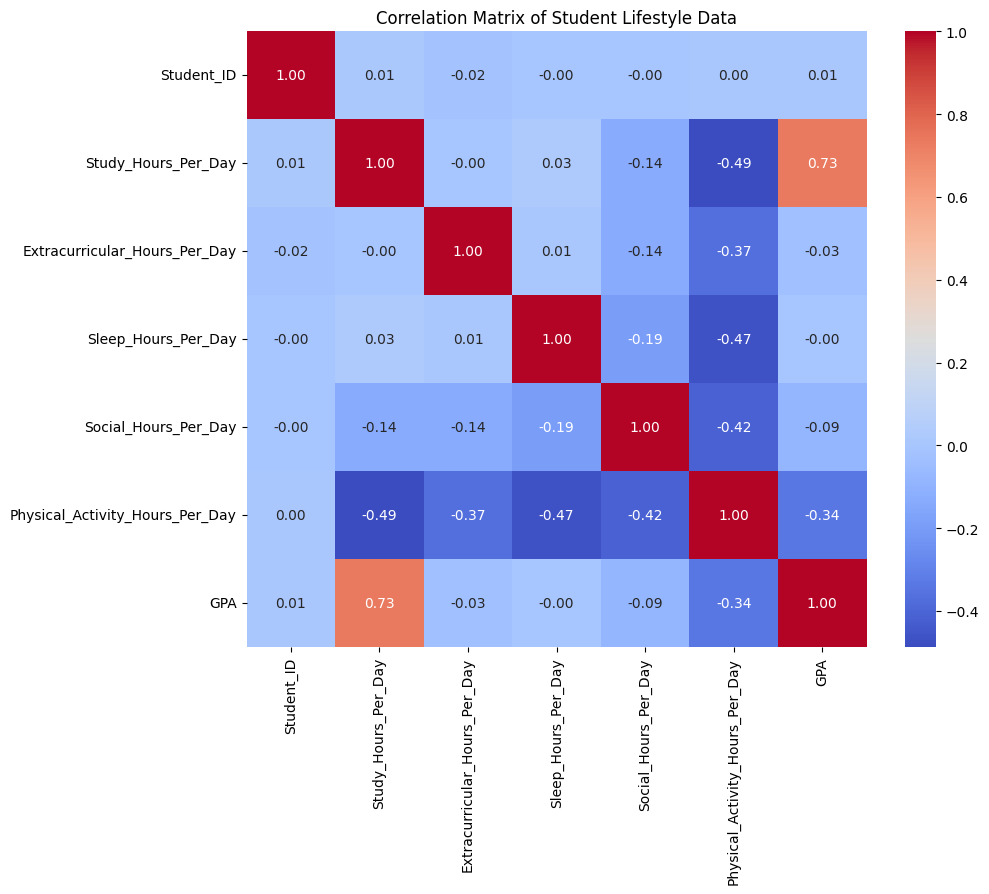

In [9]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Student Lifestyle Data')
plt.show()


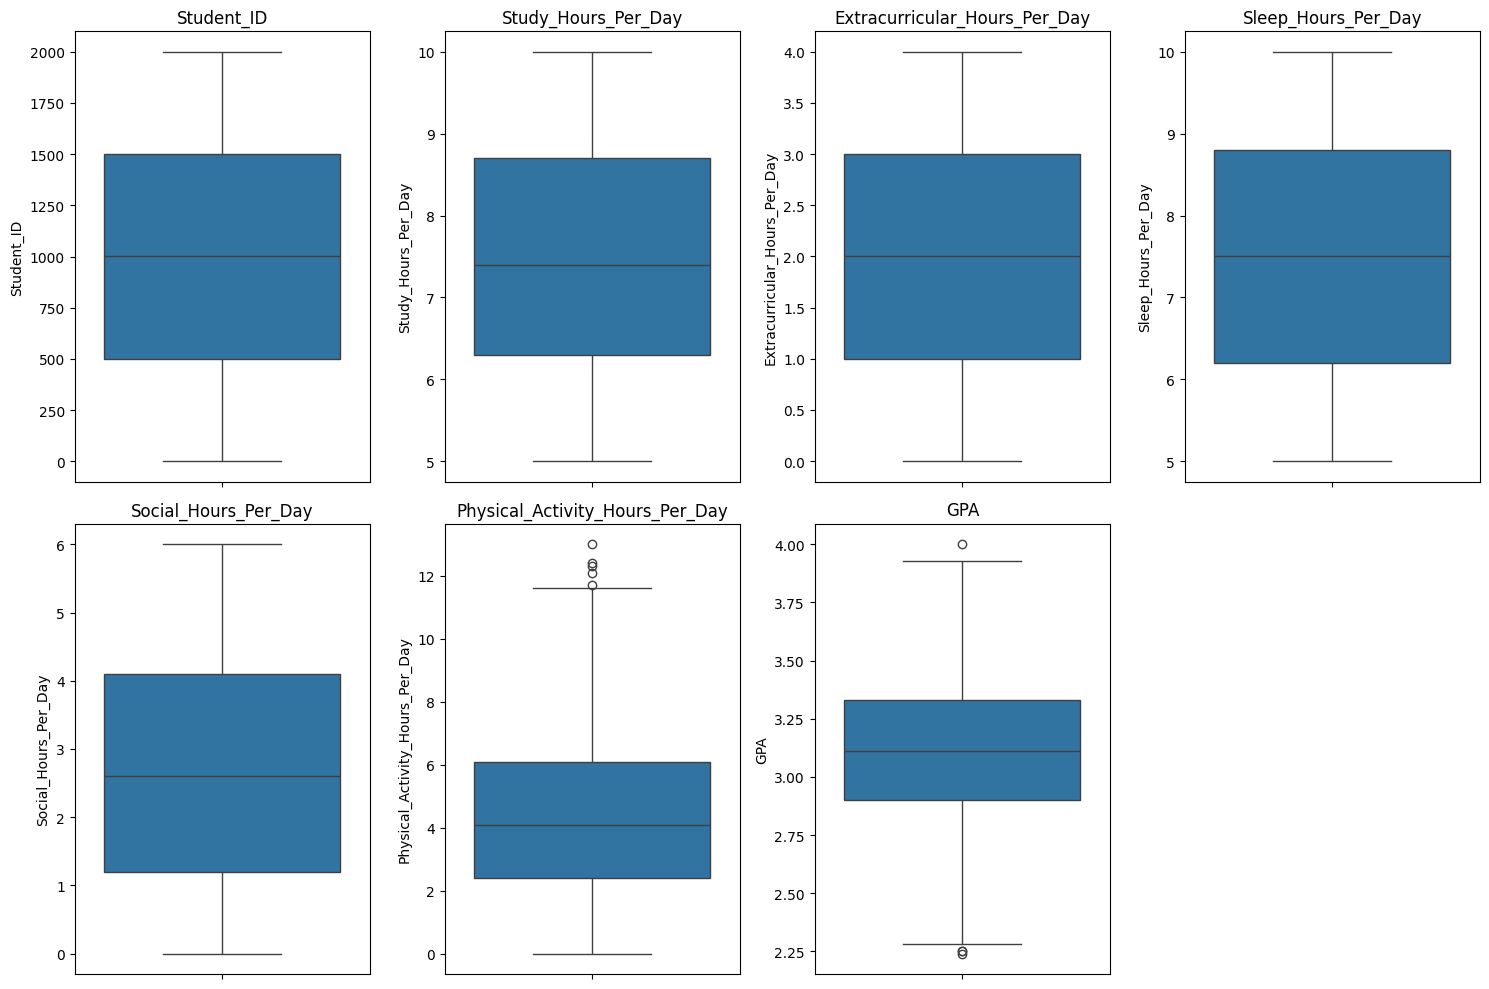

In [10]:
# Outlier detection (using box plots for numerical columns)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Preprocessing

In [17]:
df.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,6.9,3.8,8.7,2.8,1.8,2.99,2
1,5.3,3.5,8.0,4.2,3.0,2.75,1
2,5.1,3.9,9.2,1.2,4.6,2.67,1
3,6.5,2.1,7.2,1.7,6.5,2.88,2
4,8.1,0.6,6.5,2.2,6.6,3.51,3


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [13]:
df['Stress_Level'].value_counts()

,count
Stress_Level,
High,1029
Moderate,674
Low,297


In [19]:
df['GPA'].unique()

array([2.99, 2.75, 2.67, 2.88, 3.51, 2.85, 3.08, 3.2 , 2.82, 2.76, 3.43,
       2.97, 2.87, 3.4 , 3.36, 3.19, 3.16, 2.93, 2.9 , 3.34, 3.21, 2.68,
       3.29, 2.64, 2.95, 2.79, 3.25, 3.05, 3.26, 2.47, 3.24, 3.62, 3.12,
       2.58, 3.03, 2.61, 3.48, 3.07, 2.81, 3.49, 3.55, 2.6 , 3.09, 3.47,
       3.18, 4.  , 3.33, 3.11, 3.1 , 2.39, 3.39, 2.52, 2.8 , 3.67, 3.27,
       3.06, 3.38, 3.15, 2.69, 3.54, 3.37, 3.58, 2.89, 3.44, 3.35, 2.62,
       2.86, 3.78, 2.96, 3.45, 3.41, 3.22, 2.98, 3.3 , 3.28, 2.7 , 3.14,
       2.73, 3.64, 2.94, 3.57, 2.72, 2.45, 3.13, 3.59, 3.65, 3.42, 3.02,
       2.38, 2.71, 2.59, 2.46, 3.5 , 2.78, 3.52, 3.17, 2.66, 2.77, 3.77,
       3.01, 2.84, 3.23, 3.32, 3.8 , 3.84, 3.68, 2.92, 3.61, 3.31, 2.91,
       3.56, 2.5 , 2.65, 3.66, 3.46, 2.83, 3.  , 3.04, 2.25, 3.6 , 3.53,
       3.63, 2.28, 2.31, 3.75, 3.81, 3.69, 3.74, 2.74, 2.63, 2.55, 2.49,
       2.44, 2.54, 3.79, 2.48, 2.53, 2.57, 2.41, 3.71, 3.76, 2.24, 3.92,
       2.3 , 3.72, 3.73, 3.93, 2.56, 3.87, 2.42, 3.

In [14]:
df['Stress_Level'] = df['Stress_Level'].replace({"High":3,"Moderate":2,"Low":1,})

/tmp/ipython-input-3936795353.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stress_Level'] = df['Stress_Level'].replace({"High":3,"Moderate":2,"Low":1,})


In [16]:
df = df.drop("Student_ID",axis=1)

In [20]:
target = ["GPA","Stress_Level"]

In [32]:
X = df.drop(target,axis=1)
y_reg = df["GPA"]
y_clf = df["Stress_Level"]

In [33]:
X

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day
0,6.9,3.8,8.7,2.8,1.8
1,5.3,3.5,8.0,4.2,3.0
2,5.1,3.9,9.2,1.2,4.6
3,6.5,2.1,7.2,1.7,6.5
4,8.1,0.6,6.5,2.2,6.6
...,...,...,...,...,...
1995,6.5,0.2,7.4,2.1,7.8
1996,6.3,2.8,8.8,1.5,4.6
1997,6.2,0.0,6.2,0.8,10.8
1998,8.1,0.7,7.6,3.5,4.1


## Train Test Split

In [35]:
X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [39]:
RB = RobustScaler()
X_train_RB = RB.fit_transform(X_train)
X_test_RB  = RB.transform(X_test)

## GPA model

In [43]:
reg = RandomForestRegressor(
    n_estimators=500, random_state=42, n_jobs=-1, max_depth=None
)
reg.fit(X_train_RB, yreg_train)

yreg_pred = reg.predict(X_test_RB)
rmse = mean_squared_error(yreg_test, yreg_pred)
mae  = mean_absolute_error(yreg_test, yreg_pred)
r2   = r2_score(yreg_test, yreg_pred)

print("GPA (Regression)")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

GPA (Regression)
RMSE: 0.044 | MAE: 0.168 | R²: 0.486


## Stress_Level model

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Stress_Level (Classification) ===
              precision    recall  f1-score   support

         low       0.79      0.98      0.88        59
    moderate       0.80      0.81      0.80       135
        high       0.89      0.83      0.86       206

    accuracy                           0.84       400
   macro avg       0.83      0.87      0.85       400
weighted avg       0.85      0.84      0.84       400



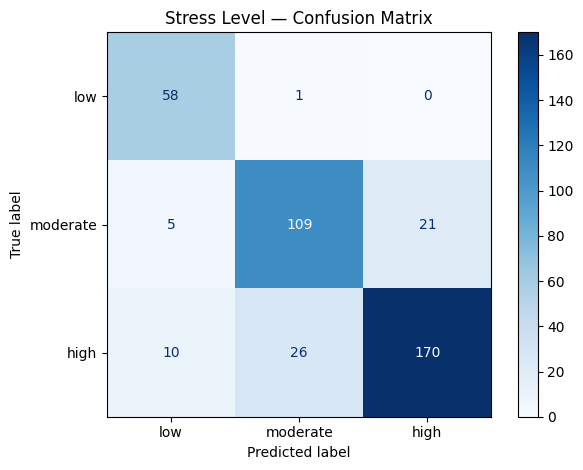

In [44]:
clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced"  # helpful if 1/2/3 are imbalanced
)
clf.fit(X_train_RB, yclf_train)

yclf_pred = clf.predict(X_test_RB)
print("\n=== Stress_Level (Classification) ===")
print(classification_report(yclf_test, yclf_pred,
                            target_names=["low","moderate","high"]))

ConfusionMatrixDisplay.from_predictions(
    yclf_test, yclf_pred, display_labels=["low","moderate","high"],
    cmap="Blues", values_format="d"
)
plt.title("Stress Level — Confusion Matrix")
plt.tight_layout()
plt.show()

In [48]:
def predict_both(X_new: np.ndarray):
    X_new_sc = RB.transform(X_new)
    gpa_hat = reg.predict(X_new_sc)
    stress_hat = clf.predict(X_new_sc)
    return gpa_hat, stress_hat



In [49]:
# Example:
gpa_hat, stress_hat = predict_both(X_test[:5])
print(gpa_hat, stress_hat)

[2.76922 3.1979  2.9523  2.89114 3.43194] [1 3 2 2 3]


Due to imbalanceness result are not that good you can balance it try again and check results :)